# Part 1 · Learn, implement and verify tabular Q-learning

## Rules

| Requirement or edge case | Implementation |
|---|---|
| Grid and B | Configurable size and delivery target; assessed run is 5×5 with B at displayed (5,5) |
| Lake | Configurable fixed cell; displayed (3,4), internal (2,3), in the main run |
| Movement | Eight actions, all available to the learner; cardinal and diagonal moves each count as one step |
| Lake entry | The agent moves onto the lake and receives **exactly −10**, not −11; the episode continues |
| Ordinary move | −1, including rejected attempts beyond the grid |
| Delivery | Exactly +100, automatically at B while carrying; episode terminates |
| Lake and B overlap | Rejected explicitly so delivery and lake rewards cannot conflict |
| Start and A | Independently sampled from **all** cells, including the lake; no scenarios are silently removed |
| A in the lake | Entering it both collects the item and incurs −10; carrying is retained |
| Start in the lake | No entry reward at reset; the agent can leave immediately |
| Start=A | Main run follows literal entry: leave and re-enter to collect |
| A=B | Entering B collects and delivers in that same move |
| Alternative reset convention | `pickup_on_reset=True` collects immediately when starting on A; checked separately |
| Boundaries | Reject the entire invalid move; staying on an edge lake via an invalid action is not another entry |
| Diagonal corner rule | Only the destination cell matters; neighbouring lake cells do not block a diagonal |
| Training cap | Truncates exploration without changing a nonterminal state into successful delivery |


The learner is not forbidden from entering the lake. Avoidance must be learned from reward. Lake position is fixed during a run, so it does not add an observation dimension. If the lake moved between episodes, its location would need to be observed and encoded.

Scenario accounting: with the main strict-entry convention, 600 scenarios have A outside the lake and can be solved without any lake entry after reset. The other 25 have A in the lake and require one entry. Of the 600, 576 also have their start outside the lake. All 625 remain in the delivery denominator.

1×1 exception: literal entry is impossible with no valid moves. Use pickup_on_reset=True and lake=None for an immediate zero-move task. A lake cannot coincide with the only delivery cell.


## Imports and experiment settings

In [1]:
%pip install numpy
%pip install matplotlib

In [2]:
import sys
import time
import unittest
from collections import deque
from dataclasses import dataclass, field, replace
from enum import IntEnum
from itertools import product
from typing import TypeAlias, TypedDict

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from numpy.typing import NDArray

Cell: TypeAlias = tuple[int, int]
State: TypeAlias = tuple[int, int, int, int, int]
QTable: TypeAlias = NDArray[np.float64]
QueueItem: TypeAlias = tuple[Cell, int]

N = 5
B: Cell = (N - 1, N - 1)
LAKE: Cell | None = (
    (N // 2, min(N - 1, N // 2 + 1))
    if N >= 3
    else ((0, N - 1) if N == 2 else None)
)
SEED = 0
PICKUP_ON_RESET = False
MAX_EPISODES = 19_000
ALPHA = 1.0
GAMMA = 0.95
EPSILON_START = 1.0
EPSILON_END = 0.1
DECAY_EPISODES = 15_000
EVALUATE_EVERY = 1_000
ASSESSMENT_LIMIT = 10

DEFAULT_MAX_STEPS = 100
DELIVERY_REWARD = 100.0
LAKE_REWARD = -10.0
STEP_REWARD = -1.0
TRAINING_SEED_OFFSET = 100_000
SNAPSHOT_EPISODES = frozenset((100, 500))
MAX_ALLOWED_EPISODES = 20_000
COORDINATE_COUNT = 2
INFINITE_DISTANCE = float("inf")

COLOR_BEFORE_PICKUP = "#c2410c"
COLOR_CARRYING = "#2563eb"
COLOR_DELIVERED = "#16a34a"
COLOR_ITEM = "#eab308"
COLOR_LAKE = "#bae6fd"
COLOR_LAKE_EDGE = "#0284c7"
COLOR_TEXT = "#0c4a6e"
COLOR_BORDER = "#64748b"

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__, "| Matplotlib:", matplotlib.__version__)
print("Internal B:", B, "| Display B:", tuple(v + 1 for v in B))
display_lake = None if LAKE is None else tuple(v + 1 for v in LAKE)
print("Internal lake:", LAKE, "| Display lake:", display_lake)


Python: 3.13.15
NumPy: 2.1.3 | Matplotlib: 3.10.0
Internal B: (4, 4) | Display B: (5, 5)
Internal lake: (2, 3) | Display lake: (3, 4)


## Actions, observations and rewards

An action is an index into the eight row/column changes. For example, `(-1,1)` moves up-right. The observation remains `(row, column, A_row, A_column, carrying)`, where carrying is 0 or 1. B and the lake are fixed environment settings; A is explicitly observed from the start.

The reward is

$$
r=\begin{cases}
100 & \text{successful delivery},\\
-10 & \text{valid movement enters the lake},\\
-1 & \text{otherwise}.
\end{cases}
$$

The lake is not a terminal failure, and it does not remove an item already being carried. An item in the lake still has to be collected. There is no pickup bonus. Both lake entry and delivery have their stated **total** reward, replacing the ordinary −1 for that move.

Why a detour can help: from displayed (2,3), collect at A=(4,5), then deliver at B=(5,5). The direct three-move route enters the lake and receives rewards [-10, -1, 100]. A four-move route avoiding it receives [-1, -1, -1, 100]. At gamma=0.95 their discounted returns are 79.3 and 82.885 respectively, so the detour is more valuable.

In [3]:
class Direction(IntEnum):
    UP = 0
    DOWN = 1
    LEFT = 2
    RIGHT = 3
    UP_LEFT = 4
    UP_RIGHT = 5
    DOWN_LEFT = 6
    DOWN_RIGHT = 7


ACTIONS: tuple[Cell, ...] = (
    (-1, 0), (1, 0), (0, -1), (0, 1),
    (-1, -1), (-1, 1), (1, -1), (1, 1),
)
ACTION_NAMES: tuple[str, ...] = (
    "up", "down", "left", "right",
    "up-left", "up-right", "down-left", "down-right",
)

for action, (name, change) in enumerate(zip(ACTION_NAMES, ACTIONS)):
    print(f"{action}: {name:10s} changes position by {change}")


0: up         changes position by (-1, 0)
1: down       changes position by (1, 0)
2: left       changes position by (0, -1)
3: right      changes position by (0, 1)
4: up-left    changes position by (-1, -1)
5: up-right   changes position by (-1, 1)
6: down-left  changes position by (1, -1)
7: down-right changes position by (1, 1)


## Implement the environment

A `class` is a blueprint for independent environments. Each instance has its own position, A, carrying flag, episode counters and random generator. `self` refers to that instance. `__init__` sets it up. A method is a function attached to the instance.

Read this cell by method:

| Method | Responsibility |
|---|---|
| `__init__` | Validate settings and create episode variables |
| `validate_cell` | Check coordinates and convert NumPy integers to ordinary integers |
| `observation` | Return a fresh, immutable five-element tuple |
| `reset` | Set explicit test positions or sample random training positions |
| `step` | Apply one action, process events, return feedback |

The learner cannot access a hidden optimal route here. The environment only enforces the task's rules.

In `step`, movement happens first, pickup second, delivery third, and the training cap last. This ordering handles A=B and delivery on the last permitted move correctly. `terminated` means delivered; `truncated` means the practical step cap was reached without delivery.


In [4]:
@dataclass(frozen=True)
class GridConfig:
    n: int = 5
    target: Cell | None = None
    max_steps: int = DEFAULT_MAX_STEPS
    seed: int = 0
    pickup_on_reset: bool = True
    lake: Cell | None = None


class StepInfo(TypedDict):
    picked_up: bool
    invalid_move: bool
    success: bool
    entered_lake: bool


StepEvents: TypeAlias = tuple[bool, bool]
StepResult: TypeAlias = tuple[State, float, bool, bool, StepInfo]


def is_plain_integer(value: int | np.integer) -> bool:
    if isinstance(value, bool):
        return False
    return isinstance(value, (int, np.integer))


def is_inside(cell: Cell, n: int) -> bool:
    row, col = cell
    row_ok = 0 <= row < n
    col_ok = 0 <= col < n
    return all((row_ok, col_ok))


def validate_cell(cell: tuple[int, int] | NDArray[np.integer],
                  n: int) -> Cell:
    if len(cell) == COORDINATE_COUNT:
        return validate_coordinates(cell, n)
    raise ValueError("A cell needs exactly two coordinates.")


def validate_coordinates(cell: tuple[int, int] | NDArray[np.integer],
                         n: int) -> Cell:
    is_valid = all(is_plain_integer(value) for value in cell)
    if is_valid:
        return normalize_cell(cell, n)
    raise ValueError("Coordinates must be integers.")


def normalize_cell(cell: tuple[int, int] | NDArray[np.integer],
                   n: int) -> Cell:
    row, col = map(int, cell)
    normalized = (row, col)
    if is_inside(normalized, n):
        return normalized
    raise ValueError("Cell is outside the grid.")


def validate_grid_config(config: GridConfig) -> None:
    validate_grid_size(config.n)
    validate_max_steps(config.max_steps)
    validate_grid_relationships(config)


def validate_grid_size(n: int) -> None:
    is_valid = all((type(n) is int, n > 0))
    if is_valid:
        return
    raise ValueError("n must be a positive integer.")


def validate_max_steps(max_steps: int) -> None:
    is_valid = all((type(max_steps) is int, max_steps > 0))
    if is_valid:
        return
    raise ValueError("max_steps must be a positive integer.")


def validate_grid_relationships(config: GridConfig) -> None:
    target = resolve_target(config)
    lake = resolve_lake(config)
    validate_distinct_cells(target, lake)
    validate_entry_semantics(config)


def resolve_target(config: GridConfig) -> Cell:
    default_target = (config.n - 1, config.n - 1)
    selected = default_target if config.target is None else config.target
    return validate_cell(selected, config.n)


def resolve_lake(config: GridConfig) -> Cell | None:
    if config.lake is None:
        return None
    return validate_cell(config.lake, config.n)


def validate_distinct_cells(target: Cell, lake: Cell | None) -> None:
    is_distinct = target != lake
    if is_distinct:
        return
    raise ValueError("The lake and delivery target must be different cells.")


def validate_entry_semantics(config: GridConfig) -> None:
    needs_entry = all((config.n == 1, config.pickup_on_reset is False))
    if needs_entry:
        raise ValueError(
            "A 1x1 grid needs pickup on reset: no entry move exists."
        )


def validate_action(action: int | np.integer) -> Direction:
    if isinstance(action, bool):
        raise ValueError("Action must be an integer from 0 to 7.")
    is_integer = isinstance(action, (int, np.integer))
    if is_integer:
        return validate_action_range(int(action))
    raise ValueError("Action must be an integer from 0 to 7.")


def validate_action_range(action: int) -> Direction:
    is_valid = action in range(len(Direction))
    if is_valid:
        return Direction(action)
    raise ValueError("Action must be an integer from 0 to 7.")


def add_delta(cell: Cell, direction: Direction) -> Cell:
    row, col = cell
    delta_row, delta_col = ACTIONS[int(direction)]
    return row + delta_row, col + delta_col



def resolve_reward(is_terminated: bool, entered_lake: bool) -> float:
    if is_terminated:
        return DELIVERY_REWARD
    if entered_lake:
        return LAKE_REWARD
    return STEP_REWARD


def make_step_info(events: StepEvents, is_valid: bool,
                   is_terminated: bool) -> StepInfo:
    return StepInfo(
        picked_up=events[1], invalid_move=is_valid is False,
        success=is_terminated, entered_lake=events[0],
    )


def ensure_active(env: "TransportGrid") -> None:
    is_done = any((env.terminated, env.truncated))
    if is_done:
        raise RuntimeError("Reset before stepping an ended episode.")


class TransportGrid:
    def __init__(self, config: GridConfig = GridConfig()) -> None:
        validate_grid_config(config)
        self.config = config
        self.target = resolve_target(config)
        self.lake = resolve_lake(config)
        self.rng = np.random.default_rng(config.seed)
        self._initialize_episode()

    def _initialize_episode(self) -> None:
        self.position: Cell = (0, 0)
        self.pickup: Cell = (0, 0)
        self._reset_status()

    def _reset_status(self) -> None:
        self.carrying = False
        self.terminated = False
        self.truncated = False
        self.steps = 0
        self.lake_entries = 0

    def observation(self) -> State:
        return (*self.position, *self.pickup, int(self.carrying))

    def reset(self, start: Cell | None = None,
              pickup: Cell | None = None) -> State:
        self.position = self._resolve_cell(start)
        self.pickup = self._resolve_cell(pickup)
        self._reset_status()
        self._apply_reset_events()
        return self.observation()

    def _resolve_cell(self, cell: Cell | None) -> Cell:
        if cell is None:
            values = self.rng.integers(self.config.n, size=COORDINATE_COUNT)
            return validate_cell(values, self.config.n)
        return validate_cell(cell, self.config.n)

    def _apply_reset_events(self) -> None:
        is_same_cell = self.position == self.pickup
        self.carrying = all((self.config.pickup_on_reset, is_same_cell))
        self.terminated = all((self.carrying, self.position == self.target))
        if self.terminated:
            self.carrying = False

    def step(self, action: int | np.integer) -> StepResult:
        ensure_active(self)
        is_valid = self._move(validate_action(action))
        events = self._apply_events(is_valid)
        return self._build_step_result(events, is_valid)

    def _move(self, direction: Direction) -> bool:
        candidate = add_delta(self.position, direction)
        is_valid = is_inside(candidate, self.config.n)
        if is_valid:
            self.position = candidate
        return is_valid

    def _apply_events(self, is_valid: bool) -> StepEvents:
        self.steps += 1
        entered_lake = self._register_lake(is_valid)
        picked_up = self._register_pickup(is_valid)
        self._register_delivery()
        return entered_lake, picked_up

    def _register_lake(self, is_valid: bool) -> bool:
        entered_lake = all((is_valid, self.position == self.lake))
        if entered_lake:
            self.lake_entries += 1
        return entered_lake

    def _register_pickup(self, is_valid: bool) -> bool:
        is_empty = self.carrying is False
        is_pickup = all((is_valid, is_empty, self.position == self.pickup))
        if is_pickup:
            self.carrying = True
        return is_pickup

    def _register_delivery(self) -> None:
        self.terminated = all((self.carrying, self.position == self.target))
        if self.terminated:
            self.carrying = False

    def _build_step_result(self, events: StepEvents,
                           is_valid: bool) -> StepResult:
        self._set_truncation()
        reward = resolve_reward(self.terminated, events[0])
        info = make_step_info(events, is_valid, self.terminated)
        return (
            self.observation(), reward, self.terminated, self.truncated, info
        )

    def _set_truncation(self) -> None:
        is_at_cap = self.steps >= self.config.max_steps
        is_active = self.terminated is False
        self.truncated = all((is_at_cap, is_active))


## Check the rules before learning

In [5]:
TEST = unittest.TestCase()
EXPECTED_CENTRE_MOVES: tuple[Cell, ...] = (
    (1, 2), (3, 2), (2, 1), (2, 3),
    (1, 1), (1, 3), (3, 1), (3, 3),
)


def make_test_grid(**changes: int | bool | Cell | None) -> TransportGrid:
    base = GridConfig(n=5, pickup_on_reset=False)
    config = replace(base, **changes)
    return TransportGrid(config)


def check_movement() -> None:
    env = make_test_grid()
    for action, destination in enumerate(EXPECTED_CENTRE_MOVES):
        env.reset(start=(2, 2), pickup=(4, 0))
        env.step(action)
        assert env.position == destination


def check_boundary_rejection() -> None:
    env = make_test_grid()
    env.reset(start=(0, 0), pickup=(2, 2))
    _, reward, done, cut, info = env.step(Direction.UP_RIGHT)
    assert env.position == (0, 0)
    result = (reward, done, cut, info["invalid_move"])
    assert result == (-1.0, False, False, True)


def check_empty_target() -> None:
    env = make_test_grid()
    env.reset(start=(4, 3), pickup=(0, 0))
    _, reward, done, _, _ = env.step(Direction.RIGHT)
    assert reward == STEP_REWARD
    assert done is False


def check_pickup_and_delivery() -> None:
    env = make_test_grid()
    env.reset(start=(4, 2), pickup=(4, 3))
    state, reward, done, _, info = env.step(Direction.RIGHT)
    result = (state[-1], info["picked_up"], reward, done)
    assert result == (1, True, -1.0, False)
    state, reward, done, cut, _ = env.step(Direction.RIGHT)
    assert (reward, done, cut, state[-1]) == (100.0, True, False, 0)


def check_ended_episode_guard() -> None:
    env = make_test_grid()
    env.reset(start=(4, 2), pickup=(4, 3))
    env.step(Direction.RIGHT)
    env.step(Direction.RIGHT)
    with TEST.assertRaises(RuntimeError):
        env.step(Direction.RIGHT)


def check_same_pickup_and_target() -> None:
    env = make_test_grid()
    env.reset(start=(3, 3), pickup=(4, 4))
    _, reward, done, _, info = env.step(Direction.DOWN_RIGHT)
    assert (done, info["picked_up"], reward) == (True, True, 100.0)


def check_strict_entry() -> None:
    env = make_test_grid()
    env.reset(start=(0, 0), pickup=(0, 0))
    env.step(Direction.UP)
    assert env.carrying is False
    env.step(Direction.RIGHT)
    assert env.carrying is False


def check_strict_entry_result() -> None:
    env = make_test_grid()
    env.reset(start=(0, 0), pickup=(0, 0))
    env.step(Direction.RIGHT)
    env.step(Direction.LEFT)
    assert env.carrying


def check_time_limit() -> None:
    env = make_test_grid(max_steps=1)
    env.reset(start=(0, 0), pickup=(3, 3))
    _, _, done, cut, _ = env.step(Direction.RIGHT)
    assert (done, cut) == (False, True)


def check_delivery_on_limit() -> None:
    env = make_test_grid(max_steps=1)
    env.reset(start=(3, 3), pickup=(4, 4))
    _, reward, done, cut, _ = env.step(Direction.DOWN_RIGHT)
    assert (done, cut, reward) == (True, False, 100.0)


def check_different_size() -> None:
    config = GridConfig(n=3, target=(1, 1), pickup_on_reset=False)
    env = TransportGrid(config)
    env.reset(start=(0, 0), pickup=(1, 1))
    assert env.step(Direction.DOWN_RIGHT)[2]


def check_single_cell() -> None:
    env = TransportGrid(GridConfig(n=1, pickup_on_reset=True))
    env.reset()
    assert (env.terminated, env.steps) == (True, 0)
    with TEST.assertRaises(ValueError):
        TransportGrid(GridConfig(n=1, pickup_on_reset=False))


def check_seed_reproducibility() -> None:
    first = TransportGrid(GridConfig(seed=42))
    second = TransportGrid(GridConfig(seed=42))
    for _ in range(5):
        assert first.reset() == second.reset()


def check_invalid_actions() -> None:
    env = make_test_grid()
    for bad_action in (-1, 8, 1.5, True):
        env.reset(start=(0, 0), pickup=(1, 1))
        with TEST.assertRaises(ValueError):
            env.step(bad_action)


check_movement()
check_boundary_rejection()
check_empty_target()
check_pickup_and_delivery()
check_ended_episode_guard()
check_same_pickup_and_target()
check_strict_entry()
check_strict_entry_result()
check_time_limit()
check_delivery_on_limit()
check_different_size()
check_single_cell()
check_seed_reproducibility()
check_invalid_actions()
print(
    "Environment checks passed: movement, boundaries, events, caps, "
    "size and seeds."
)


LakeEntryCase: TypeAlias = tuple[Cell, Direction]


def assert_lake_entry(env: TransportGrid, case: LakeEntryCase) -> None:
    start, action = case
    env.reset(start=start, pickup=(0, 0))
    _, reward, done, cut, info = env.step(action)
    assert (env.position, reward, done, cut) == ((2, 3), -10.0, False, False)
    assert (info["entered_lake"], env.lake_entries) == (True, 1)


def check_lake_entry() -> None:
    env = make_test_grid(lake=(2, 3))
    cases = (((2, 2), Direction.RIGHT), ((1, 2), Direction.DOWN_RIGHT))
    for case in cases:
        assert_lake_entry(env, case)


def check_lake_reentry() -> None:
    env = make_test_grid(lake=(2, 3))
    env.reset(start=(1, 2), pickup=(0, 0))
    env.step(Direction.DOWN_RIGHT)
    assert env.step(Direction.RIGHT)[1] == STEP_REWARD
    assert env.step(Direction.LEFT)[1] == LAKE_REWARD
    assert env.lake_entries == 2


def check_lake_pickup() -> None:
    env = make_test_grid(lake=(2, 3))
    env.reset(start=(2, 2), pickup=(2, 3))
    state, reward, done, _, info = env.step(Direction.RIGHT)
    result = (reward, state[-1], info["picked_up"], done)
    assert result == (-10.0, 1, True, False)
    assert env.step(Direction.DOWN_RIGHT)[1] == STEP_REWARD
    assert env.step(Direction.DOWN)[1] == DELIVERY_REWARD


def check_carried_item_survives_lake() -> None:
    config = GridConfig(n=5, lake=(2, 3), pickup_on_reset=True)
    env = TransportGrid(config)
    env.reset(start=(2, 2), pickup=(2, 2))
    reward = env.step(Direction.RIGHT)[1]
    assert (reward, env.carrying) == (LAKE_REWARD, True)


def check_lake_start() -> None:
    env = make_test_grid(lake=(0, 0))
    env.reset(start=(0, 0), pickup=(3, 3))
    assert env.lake_entries == 0
    assert env.step(Direction.UP)[1] == STEP_REWARD
    assert env.step(Direction.RIGHT)[1] == STEP_REWARD
    assert env.step(Direction.LEFT)[1] == LAKE_REWARD


def check_lake_target_conflict() -> None:
    config = GridConfig(n=5, target=(2, 3), lake=(2, 3))
    with TEST.assertRaises(ValueError):
        TransportGrid(config)


check_lake_entry()
check_lake_reentry()
check_lake_pickup()
check_carried_item_survives_lake()
check_lake_start()
check_lake_target_conflict()
print(
    "Lake checks passed: cardinal/diagonal entry, penalties, pickup, "
    "carrying and boundaries."
)


Environment checks passed: movement, boundaries, events, caps, size and seeds.
Lake checks passed: cardinal/diagonal entry, penalties, pickup, carrying and boundaries.


### Trace one episode by hand

It is never used for training or to choose the learned agent's actions. From displayed (1,1), it collects at (3,2) and delivers at (5,5) in five moves.

In [6]:
demo_config = GridConfig(n=5, pickup_on_reset=False, lake=(2, 3))
demo = TransportGrid(demo_config)
state = demo.reset(start=(0, 0), pickup=(2, 1))
manual_actions = (
    Direction.DOWN_RIGHT,
    Direction.DOWN,
    Direction.DOWN_RIGHT,
    Direction.DOWN_RIGHT,
    Direction.RIGHT,
)
print("Start:", state)
for action in manual_actions:
    state, reward, terminated, truncated, info = demo.step(action)
    print(
        f"{ACTION_NAMES[int(action)]:10s} state={state}, "
        f"reward={reward:6.1f}, "
        f"pickup={info['picked_up']}, delivered={terminated}"
    )
assert demo.terminated
assert demo.steps == 5


Start: (0, 0, 2, 1, 0)
down-right state=(1, 1, 2, 1, 0), reward=  -1.0, pickup=False, delivered=False
down       state=(2, 1, 2, 1, 1), reward=  -1.0, pickup=True, delivered=False
down-right state=(3, 2, 2, 1, 1), reward=  -1.0, pickup=False, delivered=False
down-right state=(4, 3, 2, 1, 1), reward=  -1.0, pickup=False, delivered=False
right      state=(4, 4, 2, 1, 0), reward= 100.0, pickup=False, delivered=True


## Create the Q-table

`Q[state]` returns eight scores: one per move in that situation. A score estimates the **discounted future reward** from choosing that action and subsequently behaving well. A Q-value is not simply the reward for the next move.

`np.zeros` starts all scores at zero. These are initial estimates, not proof that every action is equally good. Nothing is preloaded from shortest-path calculations.

In [7]:
Q_example = np.zeros((N, N, N, N, 2, len(ACTIONS)), dtype=float)
example_state = (0, 0, N - 1, 0, 0)
print('Q-table shape:', Q_example.shape)
print('Total action values:', Q_example.size)
print('Bytes:', Q_example.nbytes)
print('Eight initial scores:', Q_example[example_state])

Q-table shape: (5, 5, 5, 5, 2, 8)
Total action values: 10000
Bytes: 80000
Eight initial scores: [0. 0. 0. 0. 0. 0. 0. 0.]


## Let the agent explore: epsilon-greedy action selection

| Line or expression | Purpose |
|---|---|
| `rng.random() < epsilon` | Randomly decides whether to explore |
| `rng.integers(len(ACTIONS))` | Chooses any of the eight action numbers |
| `values = Q[state]` | Reads the scores for the current observation |
| `values == values.max()` | Finds which actions share the maximum score |
| `np.flatnonzero(...)` | Converts that Boolean mask into action indices |
| `rng.choice(best)` | Selects randomly among the best actions |
| `int(...)` | Returns an ordinary Python integer |

In [8]:
@dataclass(frozen=True)
class PolicyContext:
    epsilon: float
    rng: np.random.Generator


def random_action(rng: np.random.Generator) -> int:
    return int(rng.integers(len(ACTIONS)))


def best_actions(q_table: QTable, state: State) -> NDArray[np.intp]:
    values = q_table[state]
    return np.flatnonzero(values == values.max())


def greedy_action(q_table: QTable, state: State) -> int:
    return int(np.argmax(q_table[state]))


def choose_action(q_table: QTable, state: State,
                  context: PolicyContext) -> int:
    is_exploring = context.rng.random() < context.epsilon
    if is_exploring:
        return random_action(context.rng)
    return int(context.rng.choice(best_actions(q_table, state)))


For a nonterminal transition:
$$
Q(s,a)\leftarrow Q(s,a)+\alpha\left[r+\gamma\max_{a'}Q(s',a')-Q(s,a)\right].
$$
For actual delivery, the target is just $r$, because the episode has no future rewards.

| Symbol or variable | Meaning |
|---|---|
| `state`, $s$ | Observation before the action |
| `action`, $a$ | Chosen move |
| `reward`, $r$ | Immediate feedback from the environment |
| `next_state`, $s'$ | Observation after the move and automatic events |
| `gamma`, $\gamma$ | Discount factor: the weight of future reward |
| `alpha`, $\alpha$ | Learning rate: the fraction of the correction applied |
| `target` | Reward plus the best estimated continuation, unless terminal |
| `target - Q[index]` | Temporal-difference error: how much the estimate should change |

In [9]:
@dataclass(frozen=True)
class LearningConfig:
    alpha: float
    gamma: float


@dataclass(frozen=True)
class Transition:
    state: State
    action: int
    reward: float
    next_state: State
    terminated: bool


def td_target(q_table: QTable, transition: Transition,
              config: LearningConfig) -> float:
    if transition.terminated:
        return transition.reward
    future = float(np.max(q_table[transition.next_state]))
    return transition.reward + config.gamma * future


def q_update(q_table: QTable, transition: Transition,
             config: LearningConfig) -> None:
    index = transition.state + (transition.action,)
    current = q_table[index]
    target = td_target(q_table, transition, config)
    q_table[index] = current + config.alpha * (target - current)


In [10]:
# A hand-calculable update: 2 + 0.3 * (-1 + 0.95 * 5 - 2) = 2.525.
check_Q = np.zeros((2, 2, 2, 2, 2, 8))
s: State = (0, 0, 1, 1, 0)
s_next: State = (0, 1, 1, 1, 0)
check_Q[s + (3,)] = 2.0
check_Q[s_next] = 5.0
learning_check = LearningConfig(alpha=0.3, gamma=0.95)
transition = Transition(s, 3, -1.0, s_next, False)
q_update(check_Q, transition, learning_check)
assert np.isclose(check_Q[s + (3,)], 2.525)

# A genuine terminal transition must ignore the next-state values.
terminal = Transition(s, 3, 100.0, s_next, True)
q_update(check_Q, terminal, LearningConfig(alpha=1.0, gamma=0.95))
assert check_Q[s + (3,)] == 100.0
print("Q-update checks passed: nonterminal target 2.525; terminal target 100.")


Q-update checks passed: nonterminal target 2.525; terminal target 100.


## 10. Build the evaluator before training

The evaluator still enumerates all 25 starts × 25 A locations = **625 scenarios**. It uses a frozen table and `np.argmax`, with no exploration and no Q updates.

The benchmark first minimizes lake entries: zero when A is dry, or one required entry when A is in the lake under strict entry semantics. It then finds the shortest route under that restriction:

1. Find start→A while forbidding lake entry unless the lake itself is A.
2. Find A→B while forbidding lake entry. Starting in the lake is allowed; the first move can leave it.
3. If start=A under strict entry semantics, the first leg needs two moves to leave and return.

In [11]:
@dataclass(frozen=True)
class LegRequest:
    start: Cell
    goal: Cell
    n: int
    lake: Cell | None = None
    require_entry: bool = False


@dataclass
class SearchState:
    queue: deque[QueueItem]
    visited: set[Cell]


def distance(first: Cell, second: Cell) -> int:
    row_gap = abs(first[0] - second[0])
    col_gap = abs(first[1] - second[1])
    return max(row_gap, col_gap)


def required_same_cell_distance(request: LegRequest) -> float:
    if request.require_entry:
        return 2.0 if request.n > 1 else INFINITE_DISTANCE
    return 0.0


def is_lake_allowed(cell: Cell, request: LegRequest) -> bool:
    is_lake = cell == request.lake
    if is_lake:
        return cell == request.goal
    return True


def safe_neighbours(cell: Cell, request: LegRequest) -> list[Cell]:
    candidates = [add_delta(cell, direction) for direction in Direction]
    inside = [cell for cell in candidates if is_inside(cell, request.n)]
    return [cell for cell in inside if is_lake_allowed(cell, request)]


def add_unvisited(search: SearchState, cell: Cell, steps: int) -> None:
    is_known = cell in search.visited
    if is_known:
        return
    search.visited.add(cell)
    search.queue.append((cell, steps))


def expand_queue(search: SearchState, request: LegRequest) -> float | None:
    cell, steps = search.queue.popleft()
    for neighbour in safe_neighbours(cell, request):
        if neighbour == request.goal:
            return float(steps + 1)
        add_unvisited(search, neighbour, steps + 1)
    return None


def search_queue(search: SearchState, request: LegRequest) -> float:
    while search.queue:
        result = expand_queue(search, request)
        is_found = result is not None
        if is_found:
            return float(result)
    return INFINITE_DISTANCE


def shortest_safe_distance(request: LegRequest) -> float:
    if request.start == request.goal:
        return required_same_cell_distance(request)
    search = SearchState(deque([(request.start, 0)]), {request.start})
    return search_queue(search, request)


# The direct diagonal crosses the lake.
# The independent benchmark therefore needs a detour.
assert distance((1, 2), (3, 4)) == 2
assert shortest_safe_distance(LegRequest((1, 2), (3, 4), 5, (2, 3))) == 3
assert shortest_safe_distance(LegRequest((1, 2), (2, 3), 5, (2, 3))) == 1
assert shortest_safe_distance(LegRequest((2, 3), (4, 4), 5, (2, 3))) == 2
same_lake = LegRequest((2, 3), (2, 3), 5, (2, 3), require_entry=True)
assert shortest_safe_distance(same_lake) == 2
print(
    "Route benchmark checks passed, including lake detour "
    "and required collection."
)


Route benchmark checks passed, including lake detour and required collection.


In [12]:
@dataclass(frozen=True)
class EvaluationConfig:
    n: int = 5
    target: Cell | None = None
    cap: int = DEFAULT_MAX_STEPS
    pickup_on_reset: bool = True
    lake: Cell | None = None


@dataclass(frozen=True)
class EvaluationRecord:
    start: Cell
    pickup: Cell
    success: bool
    steps: int
    optimal_steps: float
    lake_entries: int
    required_lake_entries: int


@dataclass(frozen=True)
class EvaluationRuntime:
    env: TransportGrid
    config: EvaluationConfig


Scenario: TypeAlias = tuple[Cell, Cell]


def evaluation_grid(config: EvaluationConfig) -> TransportGrid:
    grid = GridConfig(
        n=config.n, target=config.target, max_steps=config.cap,
        pickup_on_reset=config.pickup_on_reset, lake=config.lake,
    )
    return TransportGrid(grid)


def is_episode_active(env: TransportGrid) -> bool:
    return all((env.terminated is False, env.truncated is False))


def run_greedy(
    q_table: QTable, env: TransportGrid, scenario: Scenario
) -> None:
    state = env.reset(*scenario)
    while is_episode_active(env):
        state = env.step(greedy_action(q_table, state))[0]


def make_leg(start: Cell, goal: Cell, config: EvaluationConfig) -> LegRequest:
    return LegRequest(start, goal, config.n, config.lake)


def optimal_route_steps(scenario: Scenario, config: EvaluationConfig,
                        target: Cell) -> float:
    start, pickup = scenario
    first = make_leg(start, pickup, config)
    first = replace(first, require_entry=config.pickup_on_reset is False)
    second = make_leg(pickup, target, config)
    return shortest_safe_distance(first) + shortest_safe_distance(second)


def required_lake_entries(scenario: Scenario, config: EvaluationConfig) -> int:
    start, pickup = scenario
    is_lake_pickup = pickup == config.lake
    is_reset_pickup = all((config.pickup_on_reset, start == pickup))
    return int(all((is_lake_pickup, is_reset_pickup is False)))


def build_record(runtime: EvaluationRuntime, scenario: Scenario,
                 optimal: float) -> EvaluationRecord:
    start, pickup = scenario
    required = required_lake_entries(scenario, runtime.config)
    env = runtime.env
    values = (start, pickup, env.terminated, env.steps, optimal,
              env.lake_entries, required)
    return EvaluationRecord(*values)


def evaluate_scenario(q_table: QTable, runtime: EvaluationRuntime,
                      scenario: Scenario) -> EvaluationRecord:
    run_greedy(q_table, runtime.env, scenario)
    optimal = optimal_route_steps(scenario, runtime.config, runtime.env.target)
    return build_record(runtime, scenario, optimal)


def scenarios(n: int) -> list[Scenario]:
    cells = [(int(row), int(col)) for row, col in product(range(n), repeat=2)]
    return list(product(cells, repeat=2))


def evaluate(q_table: QTable, config: EvaluationConfig = EvaluationConfig()
             ) -> list[EvaluationRecord]:
    runtime = EvaluationRuntime(evaluation_grid(config), config)
    return [
        evaluate_scenario(q_table, runtime, item)
        for item in scenarios(config.n)
    ]


In [13]:
@dataclass(frozen=True)
class Metrics:
    scenarios: int
    passed_10: int
    successes: int
    max_steps: int | None
    mean_steps: float | None
    optimal: int
    total_lake_entries: int
    required_lake_entries: int
    avoidable_lake_entries: int
    lake_avoidance_scenarios: int
    lake_avoidance_passed: int


BasicMetrics: TypeAlias = tuple[int, int, int, int | None, float | None, int]
LakeMetrics: TypeAlias = tuple[int, int, int, int, int]


def is_passed(record: EvaluationRecord) -> bool:
    return all((record.success, record.steps <= ASSESSMENT_LIMIT))


def is_optimal(record: EvaluationRecord) -> bool:
    same_steps = record.steps == record.optimal_steps
    exact_entries = record.lake_entries == record.required_lake_entries
    return all((record.success, same_steps, exact_entries))


def successful_records(
    records: list[EvaluationRecord],
) -> list[EvaluationRecord]:
    return [record for record in records if record.success]


def mean_success_steps(records: list[EvaluationRecord]) -> float | None:
    if records:
        return float(np.mean([record.steps for record in records]))
    return None


def basic_metrics(records: list[EvaluationRecord]) -> BasicMetrics:
    success = successful_records(records)
    steps = [record.steps for record in success]
    first = (len(records), sum(map(is_passed, records)), len(success))
    second = (max(steps, default=None), mean_success_steps(success))
    return (*first, *second, sum(map(is_optimal, records)))


def avoidable_entries(record: EvaluationRecord) -> int:
    extra = record.lake_entries - record.required_lake_entries
    return max(0, extra)


def is_lake_avoidance_case(record: EvaluationRecord) -> bool:
    return record.required_lake_entries == 0


def passed_lake_avoidance(record: EvaluationRecord) -> bool:
    is_case = is_lake_avoidance_case(record)
    no_entries = record.lake_entries == 0
    return all((record.success, is_case, no_entries))


def lake_metrics(records: list[EvaluationRecord]) -> LakeMetrics:
    total = sum(record.lake_entries for record in records)
    required = sum(record.required_lake_entries for record in records)
    avoidable = sum(map(avoidable_entries, records))
    cases = sum(map(is_lake_avoidance_case, records))
    passed = sum(map(passed_lake_avoidance, records))
    return total, required, avoidable, cases, passed


def summary(records: list[EvaluationRecord]) -> Metrics:
    values = (*basic_metrics(records), *lake_metrics(records))
    return Metrics(*values)


In [14]:
evaluation_config = EvaluationConfig(
    n=N, target=B, pickup_on_reset=PICKUP_ON_RESET, lake=LAKE
)
untrained_records = evaluate(Q_example, evaluation_config)
print("Untrained deterministic greedy policy:", summary(untrained_records))
assert len(untrained_records) == N ** 4
benchmark_max = max(row.optimal_steps for row in untrained_records)
print("Maximum moves in the lake-avoidance benchmark:", benchmark_max)


Untrained deterministic greedy policy: Metrics(scenarios=625, passed_10=0, successes=0, max_steps=None, mean_steps=None, optimal=0, total_lake_entries=50, required_lake_entries=25, avoidable_lake_entries=48, lake_avoidance_scenarios=600, lake_avoidance_passed=0)
Maximum moves in the lake-avoidance benchmark: 8.0


## Train from scratch

- ALPHA = 1.0 replaces the current estimate with the latest target; this is an experimental choice for this deterministic environment.
- GAMMA = 0.95 discounts later rewards.
- Epsilon decreases during training, so exploratory actions still occur.
- Evaluation happens every 1,000 episodes, without exploration or Q updates.
- Early stopping means all scenarios matched the defined route benchmark. It does not establish that every Q-value has stopped changing.

In [15]:
@dataclass(frozen=True)
class TrainingConfig:
    seed: int = 0
    n: int = 5
    target: Cell | None = None
    episodes: int = 19_000
    alpha: float = 1.0
    gamma: float = 0.95
    epsilon_start: float = 1.0
    epsilon_end: float = 0.1
    decay_episodes: int = 15_000
    eval_every: int = 1_000
    verbose: bool = False
    pickup_on_reset: bool = True
    stop_when_optimal: bool = True
    lake: Cell | None = None


@dataclass(frozen=True)
class Checkpoint:
    episode: int
    metrics: Metrics


@dataclass
class TrainingLog:
    steps: list[int] = field(default_factory=list)
    returns: list[float] = field(default_factory=list)
    success: list[bool] = field(default_factory=list)
    epsilon: list[float] = field(default_factory=list)
    evaluation: list[Checkpoint] = field(default_factory=list)
    lake_entries: list[int] = field(default_factory=list)


@dataclass
class TrainingRuntime:
    env: TransportGrid
    q_table: QTable
    rng: np.random.Generator
    log: TrainingLog
    snapshots: dict[int, QTable]


@dataclass(frozen=True)
class TrainingStepContext:
    policy: PolicyContext
    learning: LearningConfig


TrainingResult: TypeAlias = tuple[QTable, TrainingLog, dict[int, QTable]]


def validate_learning_rates(config: TrainingConfig) -> None:
    alpha_ok = 0 < config.alpha <= 1
    gamma_ok = 0 <= config.gamma < 1
    if all((alpha_ok, gamma_ok)):
        return
    raise ValueError("Require 0 < alpha <= 1 and 0 <= gamma < 1.")


def validate_epsilon(config: TrainingConfig) -> None:
    end_ok = 0 <= config.epsilon_end <= 1
    order_ok = config.epsilon_end <= config.epsilon_start
    start_ok = config.epsilon_start <= 1
    if all((end_ok, order_ok, start_ok)):
        return
    raise ValueError("Require 0 <= epsilon_end <= epsilon_start <= 1.")


def validate_episode_counts(config: TrainingConfig) -> None:
    counts = (config.episodes, config.decay_episodes, config.eval_every)
    if min(counts) > 0:
        return
    raise ValueError("Episode counts must be positive.")


def validate_training_config(config: TrainingConfig) -> None:
    validate_learning_rates(config)
    validate_epsilon(config)
    validate_episode_counts(config)


def training_grid_config(config: TrainingConfig) -> GridConfig:
    cap = max(DEFAULT_MAX_STEPS, 4 * config.n * config.n)
    return GridConfig(
        n=config.n, target=config.target, max_steps=cap, seed=config.seed,
        pickup_on_reset=config.pickup_on_reset, lake=config.lake,
    )


def build_runtime(config: TrainingConfig) -> TrainingRuntime:
    env = TransportGrid(training_grid_config(config))
    rng = np.random.default_rng(config.seed + TRAINING_SEED_OFFSET)
    shape = (config.n, config.n, config.n, config.n, 2, len(ACTIONS))
    q_table = np.zeros(shape, dtype=float)
    snapshots = {0: q_table.copy()}
    return TrainingRuntime(env, q_table, rng, TrainingLog(), snapshots)


def epsilon_at(episode: int, config: TrainingConfig) -> float:
    denominator = max(1, config.decay_episodes - 1)
    fraction = min(1.0, (episode - 1) / denominator)
    change = config.epsilon_end - config.epsilon_start
    return config.epsilon_start + fraction * change


def training_step(runtime: TrainingRuntime, state: State,
                  context: TrainingStepContext) -> tuple[State, float]:
    action = choose_action(runtime.q_table, state, context.policy)
    next_state, reward, terminated, _, _ = runtime.env.step(action)
    transition = Transition(state, action, reward, next_state, terminated)
    q_update(runtime.q_table, transition, context.learning)
    return next_state, reward


def episode_loop(runtime: TrainingRuntime, state: State,
                 context: TrainingStepContext) -> float:
    total = 0.0
    while is_episode_active(runtime.env):
        state, reward = training_step(runtime, state, context)
        total += reward
    return total


def append_episode_log(runtime: TrainingRuntime, total: float,
                       epsilon: float) -> None:
    runtime.log.steps.append(runtime.env.steps)
    runtime.log.returns.append(total)
    runtime.log.success.append(runtime.env.terminated)
    runtime.log.epsilon.append(epsilon)
    runtime.log.lake_entries.append(runtime.env.lake_entries)


def run_episode(runtime: TrainingRuntime, episode: int,
                config: TrainingConfig) -> None:
    epsilon = epsilon_at(episode, config)
    policy = PolicyContext(epsilon, runtime.rng)
    learning = LearningConfig(config.alpha, config.gamma)
    context = TrainingStepContext(policy, learning)
    total = episode_loop(runtime, runtime.env.reset(), context)
    append_episode_log(runtime, total, epsilon)


def save_snapshot(runtime: TrainingRuntime, episode: int) -> None:
    is_snapshot = episode in SNAPSHOT_EPISODES
    if is_snapshot:
        runtime.snapshots[episode] = runtime.q_table.copy()


def checkpoint_due(episode: int, config: TrainingConfig) -> bool:
    is_periodic = episode % config.eval_every == 0
    is_final = episode == config.episodes
    return any((is_periodic, is_final))


def training_evaluation_config(config: TrainingConfig) -> EvaluationConfig:
    return EvaluationConfig(
        n=config.n, target=config.target,
        pickup_on_reset=config.pickup_on_reset,
        lake=config.lake,
    )


def print_checkpoint(config: TrainingConfig, checkpoint: Checkpoint) -> None:
    if config.verbose:
        print(config.seed, checkpoint.metrics, flush=True)


def should_stop(config: TrainingConfig, metrics: Metrics) -> bool:
    is_optimal = metrics.optimal == metrics.scenarios
    return all((config.stop_when_optimal, is_optimal))


def evaluate_checkpoint(runtime: TrainingRuntime, episode: int,
                        config: TrainingConfig) -> bool:
    records = evaluate(runtime.q_table, training_evaluation_config(config))
    checkpoint = Checkpoint(episode, summary(records))
    runtime.log.evaluation.append(checkpoint)
    runtime.snapshots[episode] = runtime.q_table.copy()
    print_checkpoint(config, checkpoint)
    return should_stop(config, checkpoint.metrics)


def record_checkpoint(runtime: TrainingRuntime, episode: int,
                      config: TrainingConfig) -> bool:
    is_due = checkpoint_due(episode, config)
    if is_due:
        return evaluate_checkpoint(runtime, episode, config)
    return False


def training_iteration(runtime: TrainingRuntime, episode: int,
                       config: TrainingConfig) -> bool:
    run_episode(runtime, episode, config)
    save_snapshot(runtime, episode)
    return record_checkpoint(runtime, episode, config)


def train(config: TrainingConfig = TrainingConfig()) -> TrainingResult:
    validate_training_config(config)
    runtime = build_runtime(config)
    for episode in range(1, config.episodes + 1):
        is_done = training_iteration(runtime, episode, config)
        if is_done:
            break
    return runtime.q_table, runtime.log, runtime.snapshots


In [16]:
TRAINING_CONFIG = TrainingConfig(
    seed=SEED, n=N, target=B, episodes=MAX_EPISODES,
    alpha=ALPHA, gamma=GAMMA,
    epsilon_start=EPSILON_START, epsilon_end=EPSILON_END,
    decay_episodes=DECAY_EPISODES, eval_every=EVALUATE_EVERY,
    pickup_on_reset=PICKUP_ON_RESET, lake=LAKE, verbose=True,
)

training_started = time.perf_counter()
Q, training_log, snapshots = train(TRAINING_CONFIG)
training_seconds = time.perf_counter() - training_started
trained_episodes = len(training_log.steps)
training_steps = sum(training_log.steps)
print(
    f"Actual training: {trained_episodes:,} episodes; "
    f"{training_steps:,} environment steps."
)
print(f"Elapsed time on this machine: {training_seconds:.2f} seconds.")


0 Metrics(scenarios=625, passed_10=622, successes=622, max_steps=8, mean_steps=5.167202572347267, optimal=612, total_lake_entries=26, required_lake_entries=25, avoidable_lake_entries=1, lake_avoidance_scenarios=600, lake_avoidance_passed=596)
0 Metrics(scenarios=625, passed_10=624, successes=624, max_steps=8, mean_steps=5.157051282051282, optimal=624, total_lake_entries=25, required_lake_entries=25, avoidable_lake_entries=0, lake_avoidance_scenarios=600, lake_avoidance_passed=599)
0 Metrics(scenarios=625, passed_10=625, successes=625, max_steps=8, mean_steps=5.1584, optimal=625, total_lake_entries=25, required_lake_entries=25, avoidable_lake_entries=0, lake_avoidance_scenarios=600, lake_avoidance_passed=600)
Actual training: 3,000 episodes; 165,665 environment steps.
Elapsed time on this machine: 6.05 seconds.


## 12. Freeze the learned table and check the marking target

| Metric | Definition |
|---|---|
| Pass count within 10 | Number of successful deliveries with moves ≤10, out of all 625 |
| Diagnostic success | Deliveries within the longer 100-move cap |
| Worst successful route | Maximum move count among successes; paired with failure count |
| Mean successful route | Arithmetic mean over successful episodes |
| Optimal count | Successful routes matching the shortest benchmark with no extra lake entries |
| Maximum extra moves | Maximum `actual − optimal` among successful routes |
| First recorded passing checkpoint | Earliest measured checkpoint where every scenario passed within ten |
| Training episodes and steps | Sample use for this independent trained table |

In [17]:
frozen_Q = Q.copy()
Q_before_evaluation = frozen_Q.copy()
final_config = EvaluationConfig(
    n=N, target=B, cap=DEFAULT_MAX_STEPS,
    pickup_on_reset=PICKUP_ON_RESET, lake=LAKE,
)
strict_config = replace(final_config, cap=ASSESSMENT_LIMIT)
final_records = evaluate(frozen_Q, final_config)
strict_records = evaluate(frozen_Q, strict_config)
final_metrics = summary(final_records)
strict_metrics = summary(strict_records)
assert np.array_equal(frozen_Q, Q_before_evaluation)

first_pass = next(
    (
        item.episode
        for item in training_log.evaluation
        if item.metrics.passed_10 == item.metrics.scenarios
    ),
    None,
)
extra_moves = [
    row.steps - row.optimal_steps for row in final_records if row.success
]
failures = [row for row in strict_records if row.success is False]

print("Final metrics:", final_metrics)
print("Strict ten-move evaluation:", strict_metrics)
print("Maximum extra moves:", max(extra_moves, default=None))
print("First recorded passing checkpoint:", first_pass)
print("Failed scenarios:", failures)

# Optimality is checked for any configured size; the grading gate is for 5x5.
assert len(final_records) == N ** 4
assert final_metrics.optimal == N ** 4
assert trained_episodes < MAX_ALLOWED_EPISODES
if N == 5:
    assert strict_metrics.passed_10 == 625
    assert final_metrics.max_steps <= ASSESSMENT_LIMIT
    print(
        "PASS: all 625 scenarios solved within ten moves "
        "and below 20,000 training episodes."
    )
else:
    print(
        "All configured scenarios use shortest routes; "
        "the ten-move grading gate applies to 5x5."
    )

assert final_metrics.avoidable_lake_entries == 0
assert (
    final_metrics.lake_avoidance_passed
    == final_metrics.lake_avoidance_scenarios
)
assert final_metrics.total_lake_entries == final_metrics.required_lake_entries
dry_cases = [
    row for row in final_records
    if all((row.start != LAKE, row.pickup != LAKE))
]
assert len(dry_cases) == (N * N - int(LAKE is not None)) ** 2
assert all(
    all((row.success, row.lake_entries == 0))
    for row in dry_cases
)
print(
    "Dry-start / dry-A scenarios:", len(dry_cases),
    "; all delivered with zero lake entries."
)
print("PASS: no avoidable lake entries across the complete scenario set.")


Final metrics: Metrics(scenarios=625, passed_10=625, successes=625, max_steps=8, mean_steps=5.1584, optimal=625, total_lake_entries=25, required_lake_entries=25, avoidable_lake_entries=0, lake_avoidance_scenarios=600, lake_avoidance_passed=600)
Strict ten-move evaluation: Metrics(scenarios=625, passed_10=625, successes=625, max_steps=8, mean_steps=5.1584, optimal=625, total_lake_entries=25, required_lake_entries=25, avoidable_lake_entries=0, lake_avoidance_scenarios=600, lake_avoidance_passed=600)
Maximum extra moves: 0.0
First recorded passing checkpoint: 3000
Failed scenarios: []
PASS: all 625 scenarios solved within ten moves and below 20,000 training episodes.
Dry-start / dry-A scenarios: 576 ; all delivered with zero lake entries.
PASS: no avoidable lake entries across the complete scenario set.


## Confirm coverage for every A location

Each row below groups all 25 starts for one A. This directly checks the requirement that success is independent of A's location within this fixed task. Displayed coordinates are one-based. No Q updates occur here.

In [18]:
print("A (row,col)   passed / starts   worst moves   lake entries / required")
for ar in range(N):
    for ac in range(N):
        group = [row for row in final_records if row.pickup == (ar, ac)]
        passed = sum(map(is_passed, group))
        worst = max(row.steps for row in group if row.success)
        entries = sum(row.lake_entries for row in group)
        required = sum(row.required_lake_entries for row in group)
        print(
            f"{str((ar + 1, ac + 1)):12s} {passed:2d} / {len(group):2d}"
            f"             {worst:2d}             {entries:2d} / {required:2d}"
        )
        if N == 5:
            assert passed == N * N
        assert entries == required


A (row,col)   passed / starts   worst moves   lake entries / required
(1, 1)       25 / 25              8              0 /  0
(1, 2)       25 / 25              8              0 /  0
(1, 3)       25 / 25              8              0 /  0
(1, 4)       25 / 25              8              0 /  0
(1, 5)       25 / 25              8              0 /  0
(2, 1)       25 / 25              8              0 /  0
(2, 2)       25 / 25              6              0 /  0
(2, 3)       25 / 25              6              0 /  0
(2, 4)       25 / 25              6              0 /  0
(2, 5)       25 / 25              7              0 /  0
(3, 1)       25 / 25              8              0 /  0
(3, 2)       25 / 25              6              0 /  0
(3, 3)       25 / 25              4              0 /  0
(3, 4)       25 / 25              5             25 / 25
(3, 5)       25 / 25              6              0 /  0
(4, 1)       25 / 25              8              0 /  0
(4, 2)       25 / 25              

## Repeat independent training with predeclared seeds

In [19]:
@dataclass(frozen=True)
class RepeatResult:
    seed: int
    episodes: int
    environment_steps: int
    metrics: Metrics


repeat_results = [
    RepeatResult(SEED, trained_episodes, training_steps, final_metrics)
]
for repeat_seed in (0, 1, 2, 3, 4):
    if repeat_seed == SEED:
        continue
    repeat_config = replace(
        TRAINING_CONFIG, seed=repeat_seed, verbose=False
    )
    repeat_Q, repeat_log, _ = train(repeat_config)
    measured = summary(evaluate(repeat_Q, final_config))
    repeat_results.append(
        RepeatResult(
            repeat_seed,
            len(repeat_log.steps),
            sum(repeat_log.steps),
            measured,
        )
    )

print(
    f"Seed   episodes   environment steps   passed/{N**4}   "
    f"optimal/{N**4}   worst"
)
for row in repeat_results:
    metrics = row.metrics
    print(
        f"{row.seed:4d}   {row.episodes:8,d}   "
        f"{row.environment_steps:17,d}   {metrics.passed_10:10d}   "
        f"{metrics.optimal:11d}   {metrics.max_steps:5d}"
    )
    assert metrics.optimal == N ** 4
    assert metrics.avoidable_lake_entries == 0
    if N == 5:
        assert metrics.passed_10 == 625
    assert row.episodes < MAX_ALLOWED_EPISODES
print(
    "Total episodes across these independent runs:",
    sum(row.episodes for row in repeat_results),
)
print(
    "Avoidable lake entries by seed:",
    [(row.seed, row.metrics.avoidable_lake_entries) for row in repeat_results],
)


Seed   episodes   environment steps   passed/625   optimal/625   worst
   0      3,000             165,665          625           625       8
   1      3,000             164,967          625           625       8
   2      2,000             123,914          625           625       8
   3      3,000             165,652          625           625       8
   4      2,000             127,269          625           625       8
Total episodes across these independent runs: 13000
Avoidable lake entries by seed: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0)]


## Plot learning progress

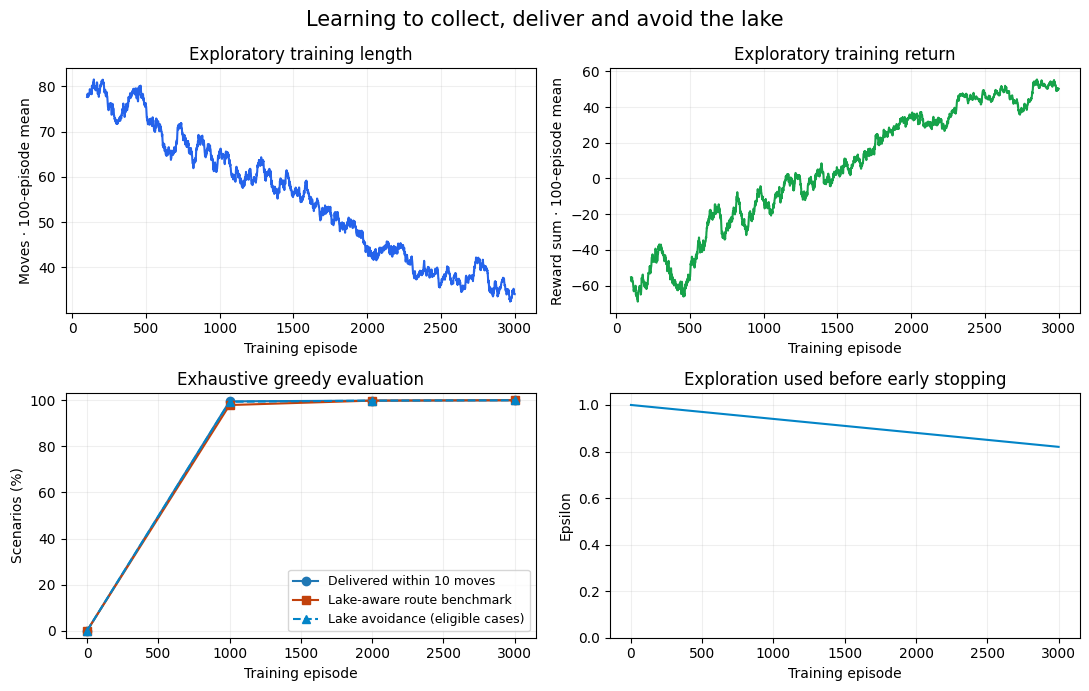

In [20]:
def moving_average(values: list[int] | list[float],
                   window: int = 100) -> NDArray[np.float64]:
    effective = min(window, len(values))
    weights = np.ones(effective) / effective
    array = np.asarray(values, dtype=float)
    return np.convolve(array, weights, mode="valid")


window = min(100, trained_episodes)
smoothed_x = np.arange(window, trained_episodes + 1)
checkpoints = training_log.evaluation
checked_x = [0] + [item.episode for item in checkpoints]
initial_summary = summary(untrained_records)
initial_pass = initial_summary.passed_10 / (N ** 4) * 100
checked_success = [initial_pass] + [
    100 * item.metrics.passed_10 / item.metrics.scenarios
    for item in checkpoints
]
checked_optimal = [
    100 * initial_summary.optimal / (N ** 4)
] + [
    100 * item.metrics.optimal / item.metrics.scenarios
    for item in checkpoints
]
checked_avoidance = [
    100
    * initial_summary.lake_avoidance_passed
    / initial_summary.lake_avoidance_scenarios
] + [
    100
    * item.metrics.lake_avoidance_passed
    / item.metrics.lake_avoidance_scenarios
    for item in checkpoints
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0, 0].plot(
    smoothed_x, moving_average(training_log.steps, window),
    color=COLOR_CARRYING,
)
axes[0, 0].set(
    title="Exploratory training length",
    ylabel="Moves · 100-episode mean",
)
axes[0, 1].plot(
    smoothed_x, moving_average(training_log.returns, window),
    color=COLOR_DELIVERED,
)
axes[0, 1].set(
    title="Exploratory training return",
    ylabel="Reward sum · 100-episode mean",
)
axes[1, 0].plot(
    checked_x, checked_success, marker="o",
    label="Delivered within 10 moves",
)
axes[1, 0].plot(
    checked_x, checked_optimal, marker="s",
    label="Lake-aware route benchmark", color=COLOR_BEFORE_PICKUP,
)
axes[1, 0].plot(
    checked_x, checked_avoidance, marker="^", linestyle="--",
    label="Lake avoidance (eligible cases)", color=COLOR_LAKE_EDGE,
)
axes[1, 0].set(
    title="Exhaustive greedy evaluation",
    ylabel="Scenarios (%)", ylim=(-3, 103),
)
axes[1, 0].legend(fontsize=9)
axes[1, 1].plot(
    np.arange(1, trained_episodes + 1),
    training_log.epsilon,
    color=COLOR_LAKE_EDGE,
)
axes[1, 1].set(
    title="Exploration used before early stopping",
    ylabel="Epsilon", ylim=(0, 1.05),
)
for ax in axes.flat:
    ax.set_xlabel("Training episode")
    ax.grid(alpha=0.2)
fig.suptitle("Learning to collect, deliver and avoid the lake", fontsize=15)
fig.tight_layout()
plt.show()


## Plot the worst route for each pickup location

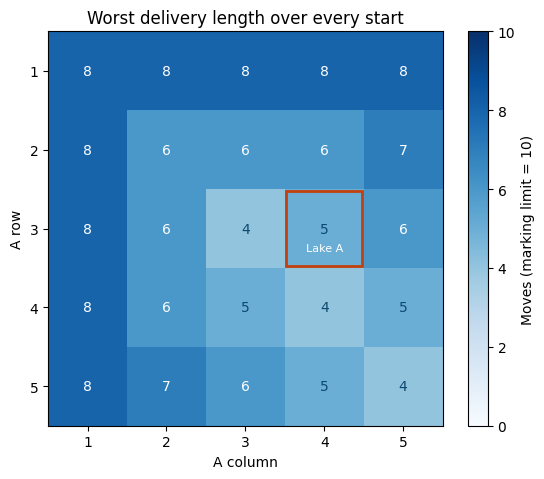

In [21]:
worst_by_A = np.zeros((N, N), dtype=int)
for row in final_records:
    ar, ac = row.pickup
    worst_by_A[ar, ac] = max(worst_by_A[ar, ac], row.steps)

fig, ax = plt.subplots(figsize=(5.8, 4.8))
picture = ax.imshow(worst_by_A, cmap="Blues", vmin=0, vmax=ASSESSMENT_LIMIT)
for ar in range(N):
    for ac in range(N):
        text_color = "white" if worst_by_A[ar, ac] >= 6 else COLOR_TEXT
        ax.text(
            ac, ar, str(worst_by_A[ar, ac]),
            ha="center", va="center", color=text_color,
        )
ax.set_xticks(range(N), labels=range(1, N + 1))
ax.set_yticks(range(N), labels=range(1, N + 1))
ax.set(
    xlabel="A column",
    ylabel="A row",
    title="Worst delivery length over every start",
)
if LAKE is not None:
    ax.add_patch(
        plt.Rectangle(
            (LAKE[1] - 0.48, LAKE[0] - 0.48), 0.96, 0.96,
            fill=False, edgecolor=COLOR_BEFORE_PICKUP, linewidth=2,
        )
    )
    ax.text(
        LAKE[1], LAKE[0] + 0.28, "Lake A",
        ha="center", fontsize=8, color="white",
    )
fig.colorbar(picture, ax=ax, label="Moves (marking limit = 10)")
fig.tight_layout()
plt.show()


## Inspect the same route at different training stages

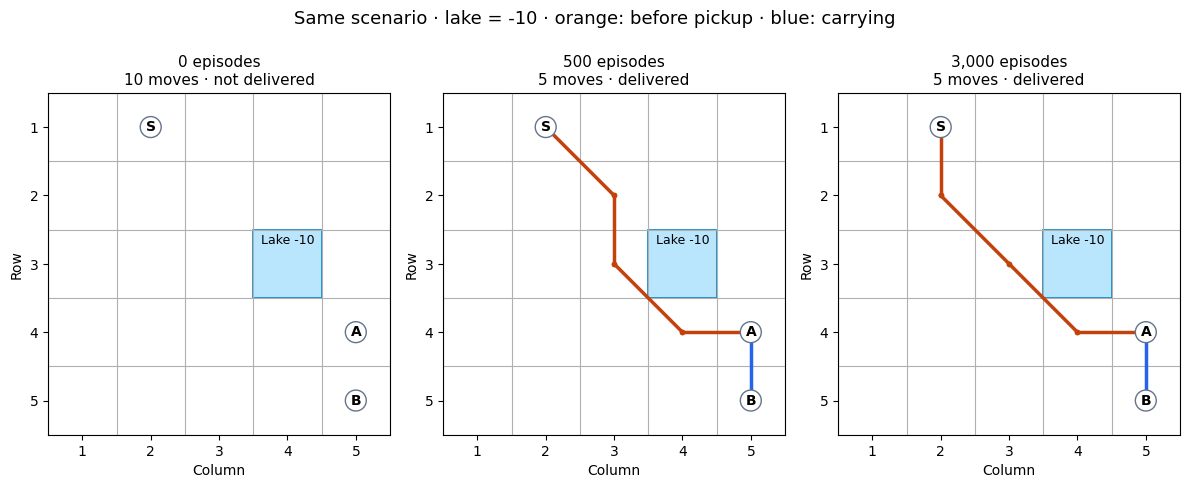

Final learned moves: ['down', 'down-right', 'down-right', 'right', 'down']
Displayed positions: [(1, 2), (2, 2), (3, 3), (4, 4), (4, 5), (5, 5)]
Final route lake entries: 0


In [22]:
@dataclass
class TraceBuffer:
    positions: list[Cell]
    carrying: list[bool]
    actions: list[int]
    rewards: list[float]


@dataclass(frozen=True)
class Trace:
    positions: tuple[Cell, ...]
    carrying: tuple[bool, ...]
    actions: tuple[int, ...]
    rewards: tuple[float, ...]
    success: bool
    steps: int
    lake_entries: int


ActionReward: TypeAlias = tuple[int, float]


def new_trace_buffer(env: TransportGrid) -> TraceBuffer:
    return TraceBuffer([env.position], [env.carrying], [], [])


def record_trace_step(buffer: TraceBuffer, env: TransportGrid,
                      event: ActionReward) -> None:
    action, reward = event
    buffer.positions.append(env.position)
    buffer.carrying.append(env.carrying)
    buffer.actions.append(action)
    buffer.rewards.append(reward)


def rollout_loop(q_table: QTable, env: TransportGrid,
                 buffer: TraceBuffer) -> None:
    state = env.observation()
    while is_episode_active(env):
        action = greedy_action(q_table, state)
        state, reward, _, _, _ = env.step(action)
        record_trace_step(buffer, env, (action, reward))


def build_trace(buffer: TraceBuffer, env: TransportGrid) -> Trace:
    values = (
        tuple(buffer.positions), tuple(buffer.carrying),
        tuple(buffer.actions), tuple(buffer.rewards),
        env.terminated, env.steps, env.lake_entries,
    )
    return Trace(*values)


def rollout(q_table: QTable, scenario: Scenario,
            config: EvaluationConfig) -> Trace:
    env = evaluation_grid(config)
    env.reset(*scenario)
    buffer = new_trace_buffer(env)
    rollout_loop(q_table, env, buffer)
    return build_trace(buffer, env)


def configure_grid(ax: Axes, n: int) -> None:
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_xticks(range(n), labels=range(1, n + 1))
    ax.set_yticks(range(n), labels=range(1, n + 1))


def configure_grid_lines(ax: Axes, n: int) -> None:
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", linewidth=0.8)
    ax.tick_params(which="minor", length=0)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")


def draw_lake(ax: Axes, lake: Cell) -> None:
    box = plt.Rectangle(
        (lake[1] - 0.5, lake[0] - 0.5), 1, 1,
        facecolor=COLOR_LAKE, edgecolor=COLOR_LAKE_EDGE, linewidth=1.2,
    )
    ax.add_patch(box)
    ax.text(lake[1], lake[0] - 0.30, "Lake -10", ha="center", fontsize=9)


def draw_grid(ax: Axes, n: int, lake: Cell | None = None) -> None:
    configure_grid(ax, n)
    configure_grid_lines(ax, n)
    has_lake = lake is not None
    if has_lake:
        draw_lake(ax, lake)


def path_color(is_carrying: bool) -> str:
    if is_carrying:
        return COLOR_CARRYING
    return COLOR_BEFORE_PICKUP


def draw_route(ax: Axes, trace: Trace) -> None:
    for index in range(1, len(trace.positions)):
        previous, current = trace.positions[index - 1:index + 1]
        color = path_color(trace.carrying[index - 1])
        ax.plot(
            [previous[1], current[1]], [previous[0], current[0]],
            color=color, linewidth=2.5, marker="o", markersize=3,
        )


def draw_location_label(ax: Axes, cell: Cell, label: str) -> None:
    box = {"facecolor": "white", "edgecolor": COLOR_BORDER,
           "boxstyle": "circle,pad=0.25"}
    ax.text(
        cell[1], cell[0], label, ha="center", va="center",
        weight="bold", bbox=box,
    )


start_demo: Cell = (0, max(0, N - 4))
pickup_demo: Cell = (max(0, N - 2), N - 1)
demo_scenario: Scenario = (start_demo, pickup_demo)
demo_config = replace(final_config, cap=ASSESSMENT_LIMIT)
stages = (0, 500, trained_episodes)
fig, axes = plt.subplots(1, 3, figsize=(12, 4.8))
for ax, episode in zip(axes, stages):
    trace = rollout(snapshots[episode], demo_scenario, demo_config)
    draw_grid(ax, N, lake=LAKE)
    draw_route(ax, trace)
    for cell, label in ((start_demo, "S"), (pickup_demo, "A"), (B, "B")):
        draw_location_label(ax, cell, label)
    outcome = "delivered" if trace.success else "not delivered"
    ax.set_title(
        f"{episode:,} episodes\n{trace.steps} moves · {outcome}",
        fontsize=11,
    )
fig.suptitle(
    "Same scenario · lake = -10 · orange: before pickup · blue: carrying",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0.04, 1, 0.93))
plt.show()

learned_trace = rollout(frozen_Q, demo_scenario, demo_config)
learned_moves = [ACTION_NAMES[action] for action in learned_trace.actions]
print("Final learned moves:", learned_moves)
print(
    "Displayed positions:",
    [
        tuple(value + 1 for value in position)
        for position in learned_trace.positions
    ],
)
print("Final route lake entries:", learned_trace.lake_entries)


## Check the alternative starting-on-A convention

In [23]:
alternative_config = replace(
    TRAINING_CONFIG, pickup_on_reset=True, verbose=False
)
alternative_Q, alternative_log, _ = train(alternative_config)
alternative_eval = replace(final_config, pickup_on_reset=True)
alternative_records = evaluate(alternative_Q, alternative_eval)
alternative_metrics = summary(alternative_records)
nontrivial = [row for row in alternative_records if row.optimal_steps > 0]

print("Immediate pickup at reset:", alternative_metrics)
print("Episodes:", len(alternative_log.steps))
print(
    "Nontrivial scenarios passed:",
    sum(row.success for row in nontrivial), "/", len(nontrivial),
)
assert alternative_metrics.optimal == N ** 4
if N == 5:
    assert alternative_metrics.passed_10 == 625
assert len(nontrivial) == N ** 4 - 1
assert all(row.success for row in nontrivial)
assert len(alternative_log.steps) < MAX_ALLOWED_EPISODES

notebook_training_total = (
    sum(row.episodes for row in repeat_results)
    + len(alternative_log.steps)
)
print(
    "Total training episodes in this notebook, including repeats "
    "and reset comparison:", notebook_training_total,
)

assert alternative_metrics.avoidable_lake_entries == 0
assert (
    alternative_metrics.lake_avoidance_passed
    == alternative_metrics.lake_avoidance_scenarios
)
print(
    "Alternative convention required / actual lake entries:",
    alternative_metrics.required_lake_entries,
    "/", alternative_metrics.total_lake_entries,
)


Immediate pickup at reset: Metrics(scenarios=625, passed_10=625, successes=625, max_steps=8, mean_steps=5.0784, optimal=625, total_lake_entries=24, required_lake_entries=24, avoidable_lake_entries=0, lake_avoidance_scenarios=601, lake_avoidance_passed=601)
Episodes: 2000
Nontrivial scenarios passed: 624 / 624
Total training episodes in this notebook, including repeats and reset comparison: 15000
Alternative convention required / actual lake entries: 24 / 24


## Final Animation

In [24]:
from matplotlib.animation import FuncAnimation

plt.rcParams["animation.html"] = "jshtml"

animation_start: Cell = (0, max(0, N - 4))
animation_pickup: Cell = (max(0, N - 2), N - 1)
animation_scenario: Scenario = (animation_start, animation_pickup)
animation_stages = sorted(
    {0, 100, trained_episodes}.intersection(snapshots)
)
animation_traces = [
    rollout(snapshots[episode], animation_scenario, demo_config)
    for episode in animation_stages
]

animation_fig, animation_axes = plt.subplots(
    1, len(animation_stages),
    figsize=(4.2 * len(animation_stages), 5),
    squeeze=False,
)
animation_fig.subplots_adjust(
    left=0.06, right=0.98, bottom=0.23, top=0.76, wspace=0.32
)
animation_fig.suptitle(
    "Learning progress: the same transport task", fontsize=15
)
animation_fig.text(
    0.5, 0.91,
    "Orange: before pickup | Blue: carrying | "
    "Green: delivered | Square: item",
    ha="center", fontsize=10,
)


@dataclass(frozen=True)
class AnimationState:
    step: int
    finished: bool
    delivered: bool
    carrying: bool


@dataclass(frozen=True)
class PanelContext:
    episode: int
    trace: Trace
    frame: int


def get_animation_state(trace: Trace, frame: int) -> AnimationState:
    step = min(frame, trace.steps)
    finished = step == trace.steps
    delivered = all((finished, trace.success))
    carrying = trace.carrying[step]
    return AnimationState(step, finished, delivered, carrying)


def draw_partial_route(ax: Axes, trace: Trace, step: int) -> None:
    for index in range(1, step + 1):
        previous, current = trace.positions[index - 1:index + 1]
        color = path_color(trace.carrying[index - 1])
        ax.plot(
            [previous[1], current[1]], [previous[0], current[0]],
            color=color, linewidth=2.5, alpha=0.7,
        )


def draw_animation_labels(ax: Axes) -> None:
    labels = ((animation_start, "S"), (animation_pickup, "A"), (B, "B"))
    for cell, label in labels:
        ax.text(
            cell[1], cell[0] + 0.30, label,
            ha="center", va="center", weight="bold", fontsize=10,
        )


def draw_item(ax: Axes, state: AnimationState) -> None:
    should_show = all((state.carrying is False, state.delivered is False))
    if should_show:
        ax.plot(
            animation_pickup[1], animation_pickup[0],
            marker="s", color=COLOR_ITEM, markersize=12, zorder=4,
        )


def agent_color(state: AnimationState) -> str:
    if state.delivered:
        return COLOR_DELIVERED
    if state.carrying:
        return COLOR_CARRYING
    return COLOR_BEFORE_PICKUP


def draw_agent(ax: Axes, trace: Trace, state: AnimationState) -> None:
    row, col = trace.positions[state.step]
    ax.plot(
        col, row, marker="o", markersize=15,
        color=agent_color(state), markeredgecolor="white", zorder=5,
    )


def animation_status(state: AnimationState) -> str:
    if state.delivered:
        return "Delivered"
    if state.finished:
        return "Step limit reached"
    if state.carrying:
        return "Carrying item"
    return "Going to A"


def is_lake_entry(pair: tuple[Cell, Cell]) -> bool:
    previous, current = pair
    moved = previous != current
    reached_lake = current == LAKE
    return all((moved, reached_lake))


def count_lake_entries(trace: Trace, step: int) -> int:
    previous = trace.positions[:step]
    current = trace.positions[1:step + 1]
    return sum(map(is_lake_entry, zip(previous, current)))


def footer_text(trace: Trace, state: AnimationState) -> str:
    lake_entries = count_lake_entries(trace, state.step)
    reward_sum = sum(trace.rewards[:state.step])
    return f"Reward sum: {reward_sum:.0f} | Lake entries: {lake_entries}"


def draw_panel_footer(ax: Axes, text: str) -> None:
    ax.text(
        0.5, -0.24, text,
        transform=ax.transAxes, ha="center", fontsize=10,
    )


def draw_panel_title(ax: Axes, context: PanelContext,
                     state: AnimationState) -> None:
    status = animation_status(state)
    ax.set_title(
        f"After {context.episode:,} training episodes\n"
        f"Move {state.step}: {status}",
        fontsize=11,
    )


def draw_panel_scene(ax: Axes, context: PanelContext,
                     state: AnimationState) -> None:
    draw_grid(ax, N, lake=LAKE)
    draw_partial_route(ax, context.trace, state.step)
    draw_animation_labels(ax)
    draw_item(ax, state)
    draw_agent(ax, context.trace, state)


def render_panel(ax: Axes, context: PanelContext) -> None:
    state = get_animation_state(context.trace, context.frame)
    ax.clear()
    draw_panel_scene(ax, context, state)
    draw_panel_title(ax, context, state)
    draw_panel_footer(ax, footer_text(context.trace, state))


def update_animation(frame: int) -> None:
    items = zip(animation_axes.flat, animation_stages, animation_traces)
    for ax, episode, trace in items:
        context = PanelContext(episode, trace, frame)
        render_panel(ax, context)


animation_frames = max(trace.steps for trace in animation_traces) + 4
learning_animation = FuncAnimation(
    animation_fig,
    update_animation,
    frames=animation_frames,
    interval=650,
    blit=False,
    repeat=False,
)

plt.close(animation_fig)
learning_animation
